In [2]:
from risk_experiment.symbolic_experiment.fit_probit import build_model, get_data
import arviz as az
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as ss
import numpy as np
import seaborn as sns
import pandas as pd
from pathlib import Path

sns.set_context('talk')

In [3]:
bids_folder = Path('/data/ds-symbolicrisk')

figure_folder = bids_folder / 'derivatives' / 'figures'
figure_folder.mkdir(parents=True, exist_ok=True)

In [26]:

def invprobit(x):
    return ss.norm.ppf(x)

def get_fake_data(data, group, model_label=None):

    unique_subjects = data.index.unique(level='subject')

    if group:
        fake_data = pd.MultiIndex.from_product([unique_subjects[:1], [0, 1], data['n_safe_bin'].unique(), ['Risky first', 'Safe first']], names=['subject', 'log_risky_safe', 'n_safe_bin', 'order']).to_frame(index=False)
    else:
        fake_data = pd.MultiIndex.from_product([unique_subjects, [0,1], data['n_safe_bin'].unique(), ['Risky first', 'Safe first']], names=['subject', 'log_risky_safe', 'n_safe_bin', 'order']).to_frame(index=False)

    if model_label == 4:
        fake_data['n_safe'] = fake_data['n_safe_bin'].apply(lambda x: np.mean(np.array(x.split('-'), dtype=float)))


    return fake_data

def extract_intercept_gamma(trace, model, data, group=False, model_label=None):

    fake_data = get_fake_data(data, group, model_label=model_label)

    pred = model.predict(trace, 'response_params', fake_data, inplace=False, include_group_specific=not group)['posterior']['p']

    pred = pred.to_dataframe().unstack([0, 1])
    pred = pred.set_index(pd.MultiIndex.from_frame(fake_data))

    # return pred

    pred0 = pred.xs(0, 0, 'log_risky_safe')
    intercept = pd.DataFrame(invprobit(pred0), index=pred0.index, columns=pred0.columns)
    gamma = invprobit(pred.xs(1, 0, 'log_risky_safe')) - intercept

    intercept = intercept.droplevel(0, 1)#,), keys=['intercept'], axis=1)
    gamma = gamma.droplevel(0, 1)#,), keys=['gamma'], axis=1)

    return intercept, gamma

In [5]:

def get_hdi(data, alpha=0.05):
    # return pd.Series(az.hdi(data.values[:, 0], alpha=alpha), index=['low', 'high'])
    return az.hdi(data.values)

In [6]:
def get_info(model_label, group=True):

    model = build_model(model_label=model_label)
    df = get_data()

    idata = az.from_netcdf(f'/data/ds-symbolicrisk/derivatives/risk_model/psychophysical/model{model_label}_samples.nc')
    intercept, gamma = extract_intercept_gamma(idata, model, df, group=group, model_label=model_label)
    rnp = np.clip(np.exp(intercept/gamma), 0, 1)
    rnp = rnp.stack([0, 1]).to_frame('rnp')
    intercept, gamma = intercept.stack([0, 1]).to_frame('intercept'), gamma.stack([0, 1]).to_frame('gamma')

    return pd.concat([intercept, gamma, rnp], axis=1)

# Model 0

/Users/gdehol/mambaforge/envs/psychophysics/lib/python3.12/site-packages/bambi/models.py:851: FutureWarning: 'mean' has been replaced by 'response_params' and is not going to work in the future
  warnings.warn(
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_46373/436184255.py:9: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  rnp = rnp.stack([0, 1]).to_frame('rnp')
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_46373/436184255.py:10: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  intercept, gamma = intercept.stack([0, 1]).to_frame('intercept'), gamm

<Axes: ylabel='Count'>

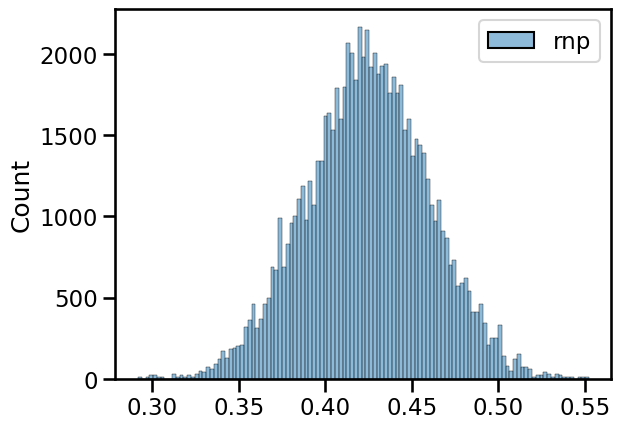

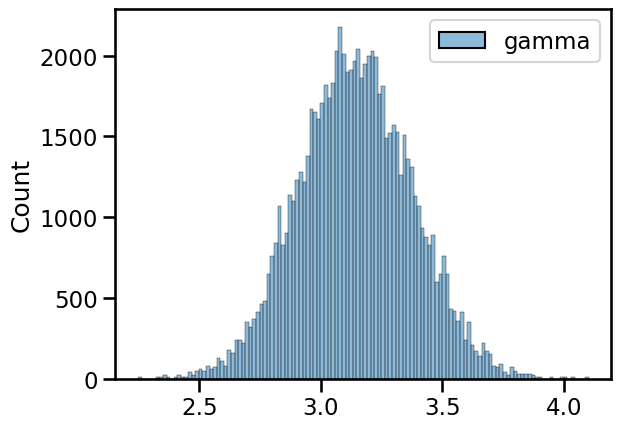

In [6]:
pars = get_info(0)

rnp, gamma = pars['rnp'].to_frame(), pars['gamma'].to_frame()

sns.histplot(rnp)

plt.figure()
sns.histplot(gamma)

In [7]:
pars = get_info(0, group=False)

/Users/gdehol/mambaforge/envs/psychophysics/lib/python3.12/site-packages/bambi/models.py:851: FutureWarning: 'mean' has been replaced by 'response_params' and is not going to work in the future
  warnings.warn(
/Users/gdehol/mambaforge/envs/psychophysics/lib/python3.12/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: overflow encountered in exp
  result = func(self.values, **kwargs)
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_46373/436184255.py:9: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  rnp = rnp.stack([0, 1]).to_frame('rnp')
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_46373/436184255.py:10: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New

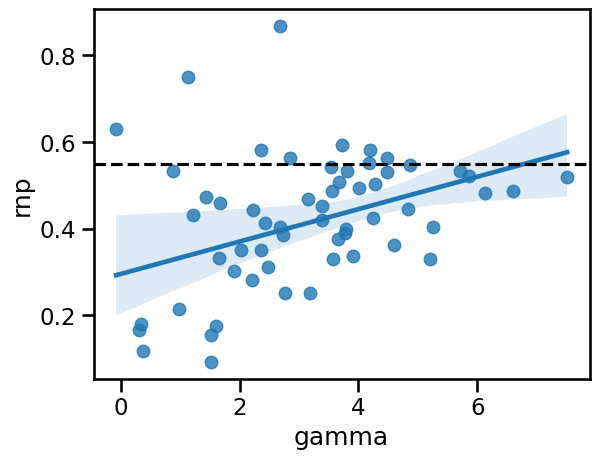

In [8]:
mean_pars = pars.groupby(['subject']).mean()

sns.regplot(data=mean_pars, x='gamma', y='rnp', robust=True)

plt.axhline(0.55, c='k', ls='--')

In [9]:
import pingouin as pg
pg.corr(mean_pars['gamma'], mean_pars['rnp'])

,n,r,CI95%,p-val,BF10,power
pearson,58,0.343865,"[0.09, 0.55]",0.00822,4.942,0.763792


/Users/gdehol/mambaforge/envs/psychophysics/lib/python3.12/site-packages/bambi/models.py:851: FutureWarning: 'mean' has been replaced by 'response_params' and is not going to work in the future
  warnings.warn(
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_3507/1031356988.py:9: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  rnp = rnp.stack([0, 1]).to_frame('rnp')
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_3507/1031356988.py:10: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  intercept, gamma = intercept.stack([0, 1]).to_frame('intercept'), gamm

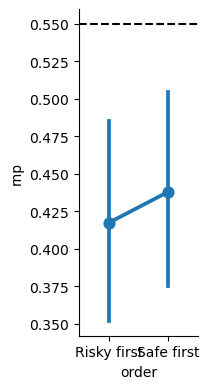

In [ ]:
pars = get_info(1, group=True)

rnp = pars['rnp']


sns.catplot(x='order', y='rnp', data=rnp.reset_index(), kind='point', height=4, aspect=.5, errorbar=get_hdi)

plt.axhline(.55, c='k', ls='--', zorder=10)

# diff = rnp.unstack('order').droplevel(0,1)

# diff = (diff['Risky first'] - diff['Safe first']).to_frame("RNP difference")

# plt.figure()
# sns.histplot(diff)

# (diff > 0.0).mean()

RNP difference    0.015875
dtype: float64

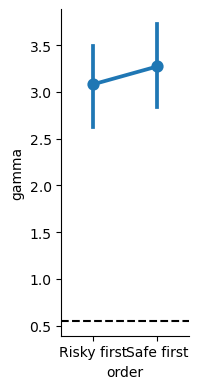

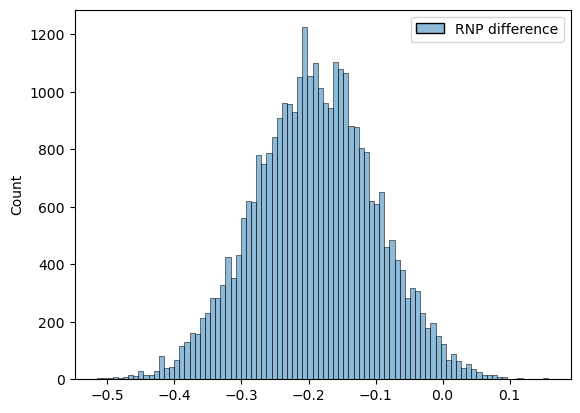

In [42]:


def get_hdi(data, alpha=0.05):
    # return pd.Series(az.hdi(data.values[:, 0], alpha=alpha), index=['low', 'high'])
    return az.hdi(data.values)

sns.catplot(x='order', y='gamma', data=gamma, kind='point', height=4, aspect=.5, errorbar=get_hdi)

plt.axhline(.55, c='k', ls='--', zorder=10)

diff = gamma.unstack('order').droplevel(0,1)

diff = (diff['Risky first'] - diff['Safe first']).to_frame("RNP difference")

plt.figure()
sns.histplot(diff)

(diff > 0.0).mean()

# Model 2

In [28]:
model_label = 2

idata = az.from_netcdf(f'/data/ds-symbolicrisk/derivatives/risk_model/psychophysical/model{model_label}_samples.nc')
pars = get_info(model_label, group=True)
rnp, gamma = pars['rnp'].to_frame(), pars['gamma'].to_frame()

# model = build_model(model_label=model_label)

# model = build_model(model_label=model_label)
# data = get_data()
# group = False

# fake_data = get_fake_data(data, group, model_label=model_label)

# pred = model.predict(idata, 'response_params', fake_data, inplace=False, include_group_specific=not group)['posterior']#['chose_risky_mean']

# # pred = pred.to_dataframe().unstack([0, 1])
# # pred = pred.set_index(pd.MultiIndex.from_frame(fake_data))

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_76565/436184255.py:9: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  rnp = rnp.stack([0, 1]).to_frame('rnp')
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_76565/436184255.py:10: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  intercept, gamma = intercept.stack([0, 1]).to_frame('intercept'), gamma.stack([0, 1]).to_frame('gamma')
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_76565/436184255.py:10: FutureWarning: The previous implementation of stack is deprecated and will be removed in a futu

In [30]:
df = get_data()

In [31]:
unique_subjects = df.index.unique(level='subject')
unique_bins = df['n_safe_bin'].unique()
log_risky_safe = np.linspace(df['log(risky/safe)'].min(), df['log(risky/safe)'].max(), 12)
order = df['order'].unique()


pred_paradigm = pd.MultiIndex.from_product([unique_subjects, log_risky_safe, unique_bins, order], names=['subject', 'log_risky_safe', 'n_safe_bin', 'order']).to_frame(index=False)

pred = model.predict(idata, data=pred_paradigm, inplace=False, kind='mean', include_group_specific=True)

/Users/gdehol/mambaforge/envs/psychophysics/lib/python3.11/site-packages/bambi/models.py:851: FutureWarning: 'mean' has been replaced by 'response_params' and is not going to work in the future
  warnings.warn(


In [33]:
p = pred['posterior']['p'].to_dataframe().unstack(-1)

p.columns = pd.MultiIndex.from_frame(pred_paradigm)
p = p.stack([0,1,2,3]).to_frame('chose_risky')

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_76565/388018005.py:4: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  p = p.stack([0,1,2,3]).to_frame('chose_risky')


In [34]:
tmp = p.groupby(['log_risky_safe', 'n_safe_bin', 'order', 'chain', 'draw']).mean()

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_76565/141120248.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp = p.groupby(['log_risky_safe', 'n_safe_bin', 'order', 'chain', 'draw']).mean()


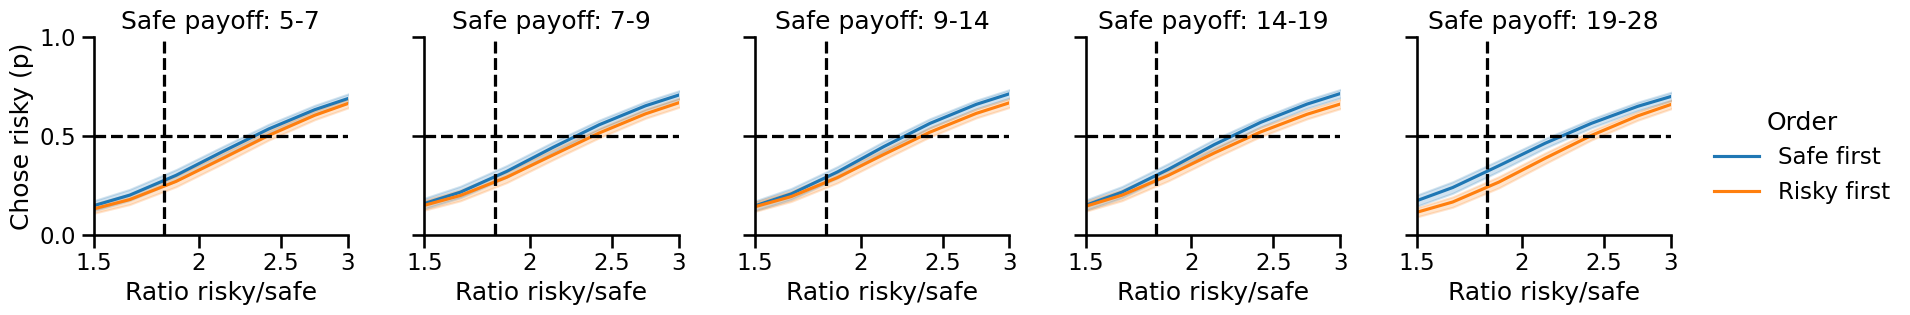

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Assuming tmp is your DataFrame and get_hdi is your function for error bars
g = sns.FacetGrid(tmp.reset_index(), hue='order', col='n_safe_bin',
                  hue_order=['Safe first', 'Risky first'], aspect=1, height=3.5,)

g.map_dataframe(sns.lineplot, x='log_risky_safe', y='chose_risky', errorbar=get_hdi)
g.add_legend(title='Order')
g.map(plt.axhline, y=0.5, c='k', ls='--', zorder=10)
g.map(plt.axvline, x=np.log(1./0.55), c='k', ls='--', zorder=10)
g.set(xticks=[np.log(1.5), np.log(2), np.log(2.5), np.log(3)], xticklabels=['1.5', '2', '2.5', '3'], xlim=(np.log(1.5), np.log(3.)))
g.set(xlabel='Ratio risky/safe', ylim=(0,1), yticks=[0, .5, 1.])
g.set_titles("Safe payoff: {col_name}")
g.set_ylabels('Chose risky (p)')

# Adjust the layout
plt.subplots_adjust(wspace=0.3, hspace=0.3)

plt.show()


g.savefig(figure_folder / f'psychophysical_model{model_label}_predictions.pdf', bbox_inches='tight')


In [36]:
indifference_ratio = 1./rnp['rnp']
indifference_ratio.name = 'indifference_ratio'

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_76565/3277274638.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for ax, (ix, ir) in zip(g.axes.flat, indifference_ratio.groupby(['n_safe_bin', 'order']).mean().groupby('n_safe_bin')):
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_76565/3277274638.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for ax, (ix, ir) in zip(g.axes.flat, indifference_ratio.groupby(['n_safe_bin', 'order']).mean().groupby('n_safe_bin')):
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_76565/3277274638.py:30: UserWarning: *c* argument looks lik

2.373353191844839
2.318478699827824
2.295843639310906
2.2511065033940953
2.219362313309105


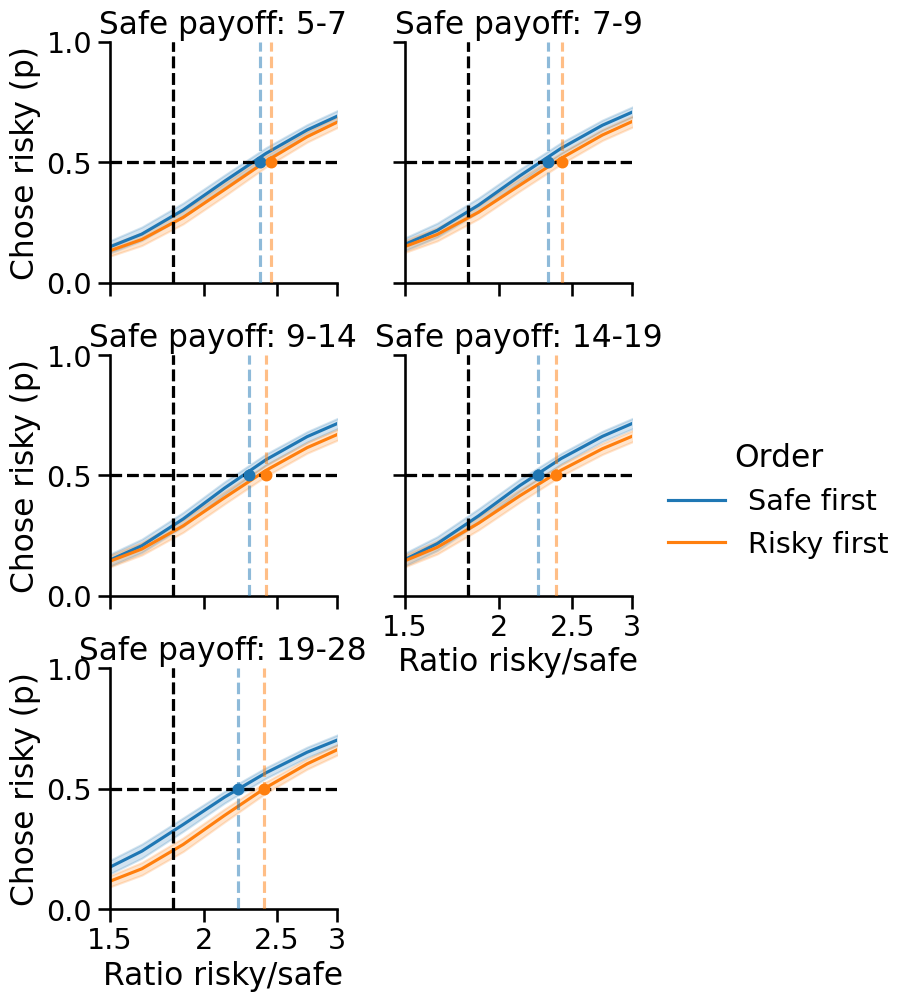

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set_context("talk", font_scale=1.25)


# Assuming tmp is your DataFrame and get_hdi is your function for error bars
g = sns.FacetGrid(tmp.reset_index(), hue='order', col='n_safe_bin',
                  hue_order=['Safe first', 'Risky first'], aspect=1, height=3.5, col_wrap=2)

g.map_dataframe(sns.lineplot, x='log_risky_safe', y='chose_risky', errorbar=get_hdi)
g.add_legend(title='Order')
g.map(plt.axhline, y=0.5, c='k', ls='--', zorder=10, label='Indifference point')
g.map(plt.axvline, x=np.log(1./0.55), c='k', ls='--', zorder=10)
g.set(xticks=[np.log(1.5), np.log(2), np.log(2.5), np.log(3)], xticklabels=['1.5', '2', '2.5', '3'], xlim=(np.log(1.5), np.log(3.)))
g.set(xlabel='Ratio risky/safe', ylim=(0,1), yticks=[0, .5, 1.])
g.set_titles("Safe payoff: {col_name}")
g.set_ylabels('Chose risky (p)')

# Adjust the layout
plt.subplots_adjust(wspace=0.3, hspace=0.3)

for ax, (ix, ir) in zip(g.axes.flat, indifference_ratio.groupby(['n_safe_bin', 'order']).mean().groupby('n_safe_bin')):
    print(ir.loc[(ix, 'Safe first')])

    ax.axvline(np.log(ir.loc[(ix, 'Safe first')]), c=sns.color_palette()[0], ls='--', zorder=50, alpha=.5)
    ax.axvline(np.log(ir.loc[(ix, 'Risky first')]), c=sns.color_palette()[1], ls='--', zorder=50, alpha=.5)

    ax.scatter(np.log(ir.loc[(ix, 'Safe first')]), 0.5, c=sns.color_palette()[0], marker='o', s=50, zorder=10)
    ax.scatter(np.log(ir.loc[(ix, 'Risky first')]), 0.5, c=sns.color_palette()[1], marker='o', s=50, zorder=10)
    
    # ax.axvline(np.log(ir.loc['Safe first']), c='k', ls='--', zorder=10, label='Indifference ratio')
    


g.savefig(figure_folder / f'psychophysical_model{model_label}_predictions_wrapped.pdf', bbox_inches='tight')

In [38]:
figure_folder

PosixPath('/data/ds-symbolicrisk/derivatives/figures')

In [39]:
np.log(2)

0.6931471805599453

In [40]:
ax.get_xticks()

array([0.40546511, 0.69314718, 0.91629073, 1.09861229])

In [41]:
g.axes[0]

<Axes: title={'center': 'Safe payoff: 5-7'}, xlabel='Ratio risky/safe', ylabel='Chose risky (p)'>

In [42]:
tmp

chose_risky
log_risky_safe n_safe_bin order       chain draw             
0.000000       5-7        Risky first 0     0        0.034605
                                            1        0.050798
                                            2        0.054703
                                            3        0.048950
                                            4        0.048976
...                                                       ...
1.386294       19-28      Safe first  3     1995     0.810376
                                            1996     0.793164
                                            1997     0.805905
                                            1998     0.824136
                                            1999     0.815925

[960000 rows x 1 columns]

In [43]:
tmp = indifference_ratio.unstack(['n_safe_bin', 'order'])

(tmp[('5-7', 'Safe first')] - tmp[('19-28', 'Safe first')]).mean(), (tmp[('5-7', 'Risky first')] - tmp[('19-28', 'Risky first')]).mean()

(0.15399087853573395, 0.05635697293005966)

In [44]:
indifference_ratio.groupby(['n_safe_bin', 'order']).mean()

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_76565/2033526203.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  indifference_ratio.groupby(['n_safe_bin', 'order']).mean()


n_safe_bin  order      
5-7         Risky first    2.457348
            Safe first     2.373353
7-9         Risky first    2.425705
            Safe first     2.318479
9-14        Risky first    2.420531
            Safe first     2.295844
14-19       Risky first    2.375616
            Safe first     2.251107
19-28       Risky first    2.400991
            Safe first     2.219362
Name: indifference_ratio, dtype: float64

In [19]:
model = build_model(model_label=model_label)

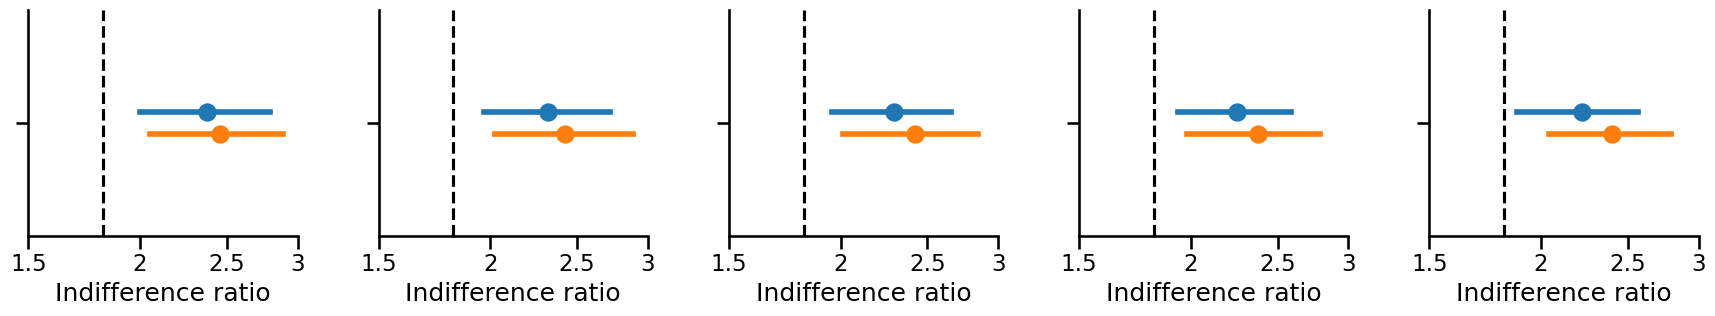

In [20]:
indifference_ratio = 1./rnp['rnp']
indifference_ratio.name = 'indifference_ratio'
indifference_ratio = indifference_ratio.to_frame('indifference_ratio')

g = sns.catplot(col='n_safe_bin', x='indifference_ratio', data=indifference_ratio.reset_index(), kind='point', height=3.5, aspect=1., errorbar=get_hdi,
            dodge=.1, hue_order=['Safe first', 'Risky first'], hue='order', legend=False)

# Make x-axis in log scale
g.set(xscale='log', )

g.set(xticks=[1.5, 2, 2.5, 3], xticklabels=['1.5', '2', '2.5', '3'], xlabel='Indifference ratio', title=None)

g.map(plt.axvline, x=1/.55, c='k', ls='--', zorder=10)

# g.set(xticks=[1./.55], xticklabels=['Risk-neutrality'], xlabel=None)

# g.axes.flat[0].set_title("Indifference ratios")
plt.subplots_adjust(wspace=0.3, hspace=0.3)
g.savefig(figure_folder / f'psychophysical_model{model_label}_indifference_ratio.pdf', bbox_inches='tight')

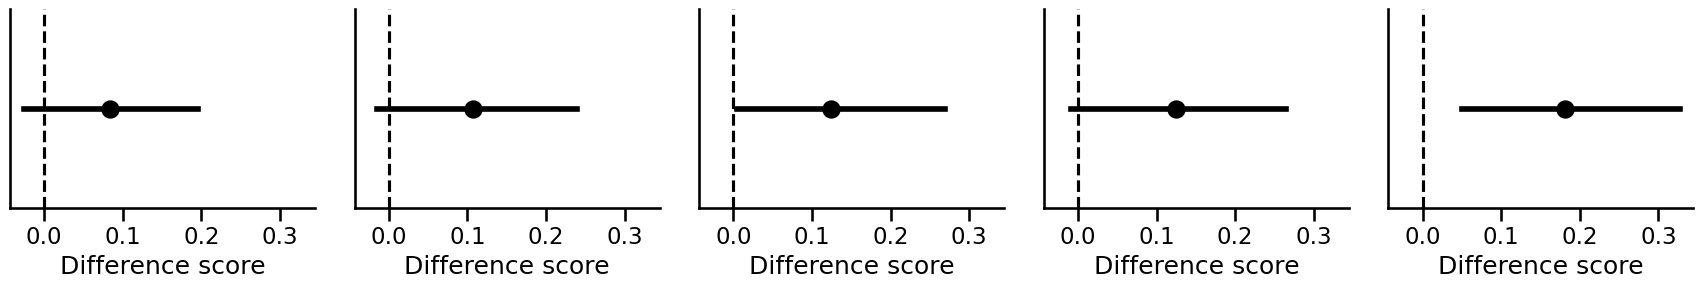

In [21]:
diff_indifference_point = indifference_ratio.unstack('order').droplevel(0,1)

diff_indifference_point = (diff_indifference_point['Risky first'] - diff_indifference_point['Safe first']).to_frame("Indifference point difference")


diff_indifference_point['dummy'] = 'a'



# sns.pointplot(y='dummy', x='Indifference point difference', data=diff_indifference_point.reset_index(), )

diff_indifference_point

g = sns.FacetGrid(diff_indifference_point.reset_index(), col='n_safe_bin', aspect=1, height=3.5)

g.map_dataframe(sns.pointplot, x='Indifference point difference', errorbar=get_hdi, color='k')

g.map(plt.axvline, x=0, c='k', ls='--', zorder=10)

g.set(yticks=[], title=None, xlabel='Difference score')

# sns.pointplot(x='Indifference point difference', data=diff_indifference_point.reset_index().iloc[::100], errorbar=get_hdi, color='k',)

g.savefig(figure_folder / f'psychophysical_model{model_label}_indifference_point_difference.pdf', bbox_inches='tight')

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_27424/3708351254.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(y='n_safe_bin', x='RNP difference', data=diff.reset_index(), kind='point', height=4, aspect=1., errorbar=get_hdi, dodge=True, palette=['k'])
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_27424/3708351254.py:18: UserWarning: 
The palette list has fewer values (1) than needed (5) and will cycle, which may produce an uninterpretable plot.
  g = sns.catplot(y='n_safe_bin', x='RNP difference', data=diff.reset_index(), kind='point', height=4, aspect=1., errorbar=get_hdi, dodge=True, palette=['k'])
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_27424/3708351254.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass 

Text(0.5, 51.0, 'Payoff safe option (binned)')

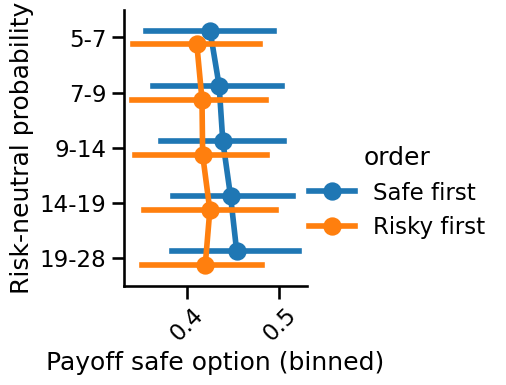

<Figure size 640x480 with 0 Axes>

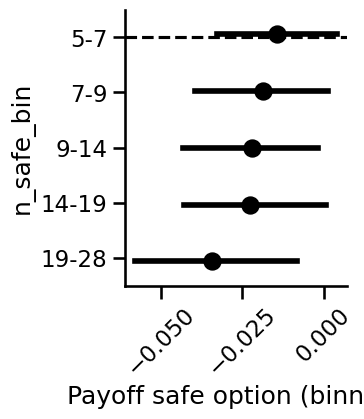

In [62]:
sns.set_context('talk')
# rnp['Order'] = rnp.index.get_level_values('order')
g = sns.catplot(y='n_safe_bin', x='rnp', data=rnp.reset_index(), hue='order', kind='point', height=4, aspect=1., errorbar=get_hdi, dodge=.25, hue_order=['Safe first', 'Risky first'],)

# g.add_legend()

# plt.axhline(.55, c='k', ls='--', zorder=10)

diff = rnp.unstack('order').droplevel(0,1)

diff = (diff['Risky first'] - diff['Safe first']).to_frame("RNP difference")

plt.xticks(rotation=45)
plt.xlabel('Payoff safe option (binned)')
plt.ylabel('Risk-neutral probability')

plt.figure()
g = sns.catplot(y='n_safe_bin', x='RNP difference', data=diff.reset_index(), kind='point', height=4, aspect=1., errorbar=get_hdi, dodge=True, palette=['k'])


g.map(plt.axhline, y=0, c='k', ls='--', zorder=10)

diff.groupby('n_safe_bin').apply(lambda x: (x > 0.0).mean())

# Rotate x-ticks for better readability
plt.xticks(rotation=45)
plt.xlabel('Payoff safe option (binned)')

# g.savefig()

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_66926/3408271696.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp = gamma.groupby(['n_safe_bin', 'chain' ,'draw']).mean().unstack(['n_safe_bin'])['gamma']


0.012375

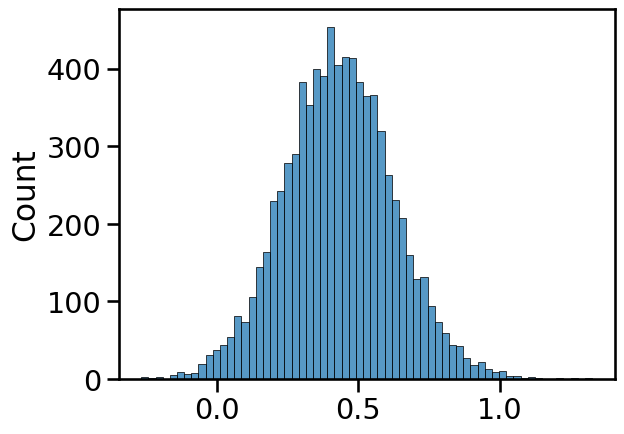

In [19]:
tmp = gamma.groupby(['n_safe_bin', 'chain' ,'draw']).mean().unstack(['n_safe_bin'])['gamma']

sns.histplot(tmp['19-28'] - tmp['5-7'])

diff = (tmp['19-28'] - tmp['5-7'])
(diff < 0.0).mean()

In [21]:
gamma.groupby(['n_safe_bin']).mean()

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_66926/3024545603.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gamma.groupby(['n_safe_bin']).mean()


,gamma
n_safe_bin,
5-7,3.202389
7-9,3.170724
9-14,3.353594
14-19,3.504092
19-28,3.632845


In [25]:
gamma.groupby('n_safe_bin').apply(get_hdi)

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_66926/1552042289.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gamma.groupby('n_safe_bin').apply(get_hdi)
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_66926/174948883.py:3: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  return az.hdi(data.values)
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_66926/174948883.py:3: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  return az.hdi(data.values)
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_66926/174948883.py:3: FutureWarning: hdi c

n_safe_bin
5-7      [[2.6832577347232145, 3.7067749386054043]]
7-9       [[2.6181231199565427, 3.734042663275684]]
9-14     [[2.7402071688260077, 3.9765414931789285]]
14-19      [[2.790375655325571, 4.207973861573123]]
19-28      [[3.043554056902259, 4.201589973044687]]
dtype: object

In [22]:
3.632845/3.20

1.1352640625

0.096

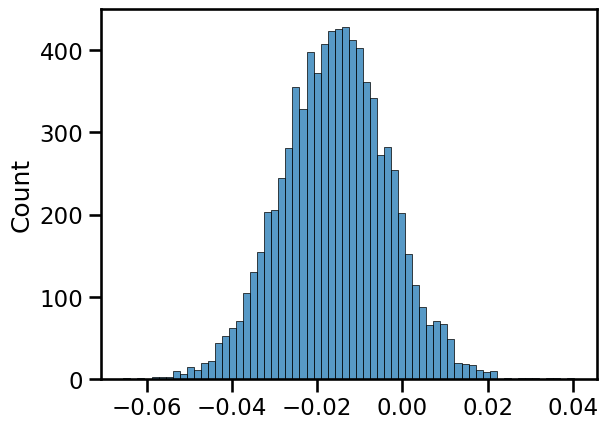

In [102]:
tmp = diff.droplevel('n_safe').unstack('n_safe_bin').droplevel(0, 1)


sns.histplot(tmp['19-28'] - tmp['5-7'])

(tmp['19-28'] - tmp['5-7'] > 0.0).mean()

In [104]:
np.array('5-7'.split('-'), dtype=float)

array([5., 7.])

In [105]:
diff['n_safe_mean'] = diff.reset_index()['n_safe_bin'].apply(lambda x: np.mean(np.array(x.split('-'), dtype=float))).values

0.096

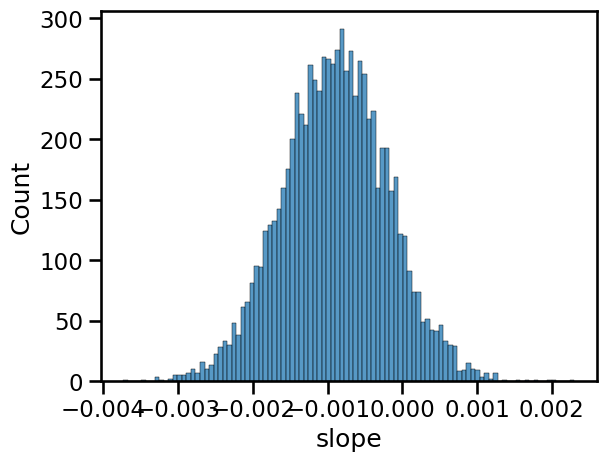

In [ ]:
from scipy import stats as ss

# Calculate the slope of the regression line for each chain and draw
def calculate_slope(group):
    x = group['n_safe_mean']
    y = group['RNP difference']
    slope, intercept, r_value, p_value, std_err = ss.linregress(x, y)
    return pd.Series({'slope': slope, 'intercept': intercept})

slope = diff.groupby(['chain', 'draw']).apply(calculate_slope)['slope']

In [22]:
pars_ind = get_info(2, group=False)



/Users/gdehol/mambaforge/envs/psychophysics/lib/python3.11/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: overflow encountered in exp
  result = func(self.values, **kwargs)
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_60335/436184255.py:9: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  rnp = rnp.stack([0, 1]).to_frame('rnp')
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_60335/436184255.py:10: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  intercept, gamma = intercept.stack([0, 1]).to_frame('intercept'), gamma.stack([0, 1]).to

In [122]:
rnp_ind = pars_ind['rnp']
gamma_ind = pars_ind['gamma']


rnp_ind_diff = rnp_ind.unstack('order')
diff_ind = (rnp_ind_diff['Risky first'] - rnp_ind_diff['Safe first']).to_frame("RNP difference")
diff_ind['n_safe_mean'] = diff_ind.reset_index()['n_safe_bin'].apply(lambda x: np.mean(np.array(x.split('-'), dtype=float))).values

# Calculate the slope of the regression line for each chain and draw
slope_ind = diff_ind.groupby(['subject', 'chain', 'draw']).apply(calculate_slope)['slope']

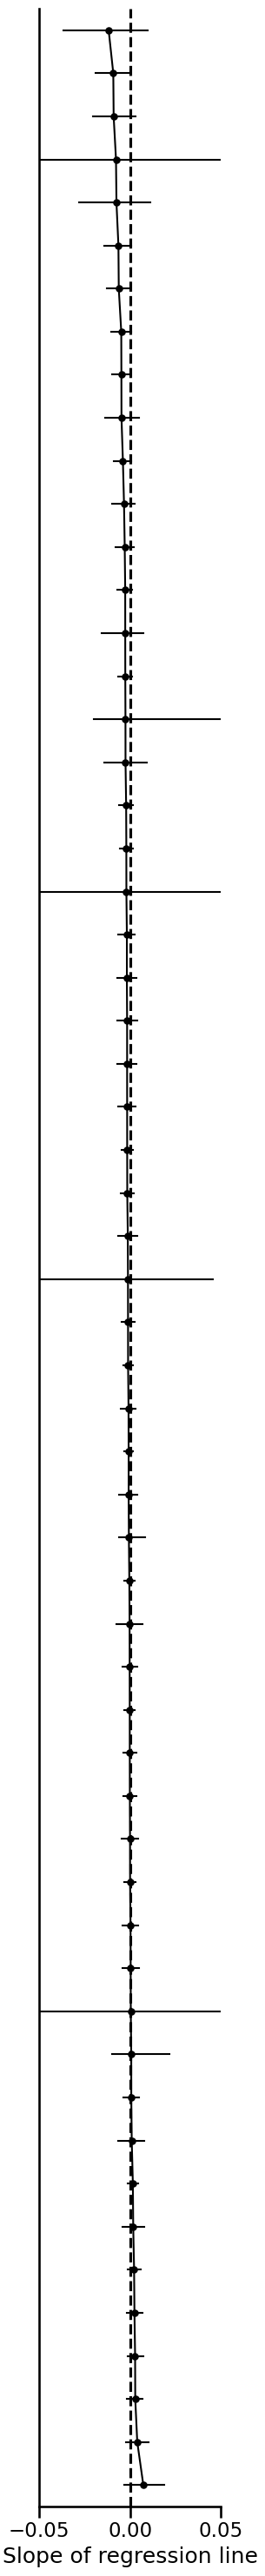

In [ ]:
order = slope_ind.groupby('subject').mean().sort_values().index

g = sns.catplot(y='subject', x='slope', data=slope_ind.reset_index(), kind='point', height=30, aspect=.1, order=order, errorbar=get_hdi, color='k', linewidth=1.5, markersize=5.)

g.set(yticks=[])

g.map(plt.axvline, x=0, c='k', ls='--', zorder=10)

g.set(xlim=(-.05, .05), xlabel='Slope of regression line', ylabel=None)

In [142]:
(slope_ind.groupby('subject').mean() < 0.0).mean()

0.7413793103448276

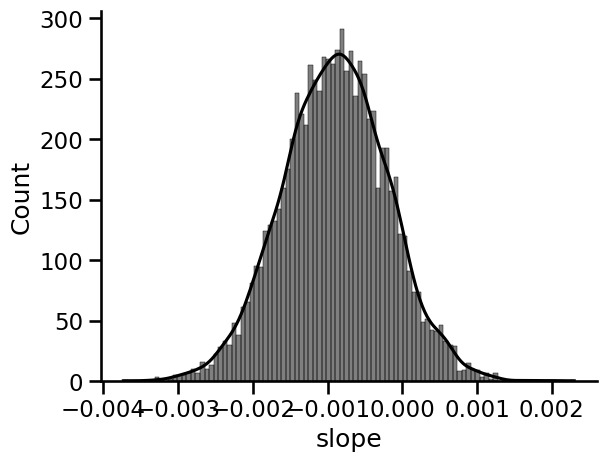

In [112]:
sns.histplot(slope, bins=100, color='k', kde=True, alpha=.5)
(slope > 0.0).mean()

sns.despine()

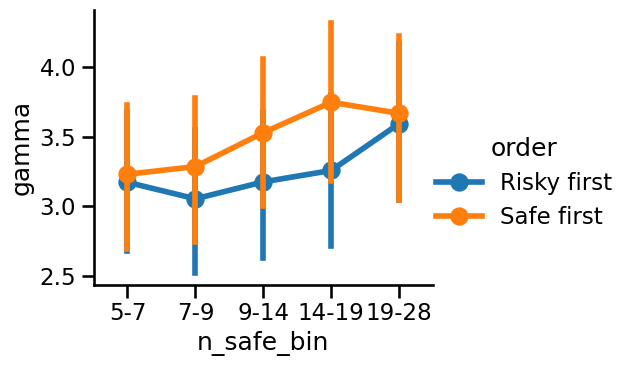

In [33]:
sns.catplot(x='n_safe_bin', hue='order', y='gamma', data=gamma.reset_index(), kind='point', height=4, aspect=1.25, errorbar=get_hdi)

RNP difference    0.0895
dtype: float64

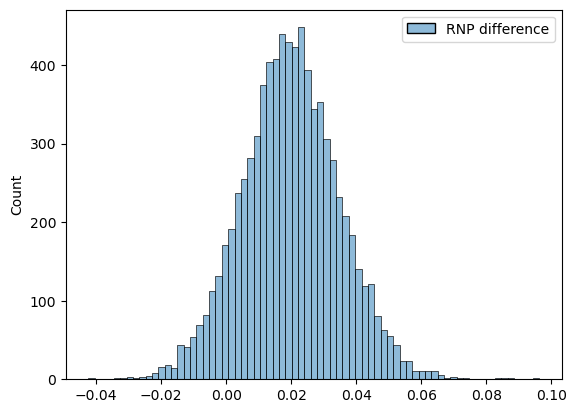

In [15]:
sns.histplot(diff.xs('5-7', level='n_safe_bin') - diff.xs('19-28', level='n_safe_bin'))

(diff.xs('5-7', level='n_safe_bin') - diff.xs('19-28', level='n_safe_bin') < 0.0).mean()

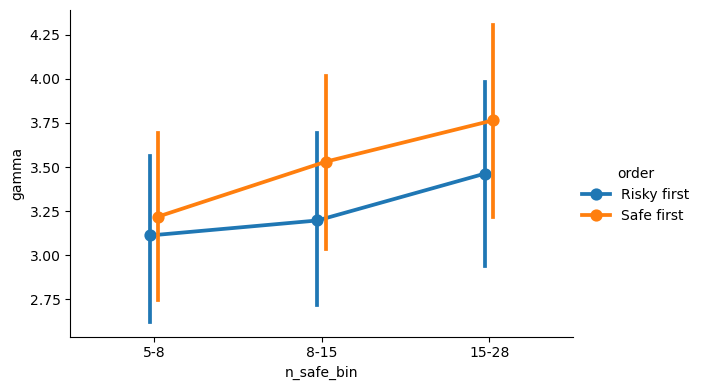

In [38]:
sns.catplot(x='n_safe_bin', y='gamma', data=gamma.reset_index(), hue='order', kind='point', height=4, aspect=1.5, errorbar=get_hdi, dodge=True)

# plt.axhline(.55, c='k', ls='--', zorder=10)

# diff = rnp.unstack('order').droplevel(0,1)

# diff = (diff['Risky first'] - diff['Safe first']).to_frame("RNP difference")

# plt.figure()
# g = sns.catplot(x='n_safe_bin', y='RNP difference', data=diff.reset_index(), kind='point', height=4, aspect=1.5, errorbar=get_hdi, dodge=True)

# g.map(plt.axhline, y=0, c='k', ls='--', zorder=10)

       Formula: chose_risky ~ log_risky_safe*C(n_safe_bin)*order + (log_risky_safe*C(n_safe_bin)*order|subject)
        Family: bernoulli
          Link: p = probit
  Observations: 14848
        Priors: 
    target = p
        Common-level effects
            Intercept ~ Normal(mu: 0.0, sigma: 8.0042)
            log_risky_safe ~ Normal(mu: 0.0, sigma: 6.5544)
            C(n_safe_bin) ~ Normal(mu: [0. 0. 0. 0.], sigma: [6.2736 6.2505 6.2379 6.2363])
            log_risky_safe:C(n_safe_bin) ~ Normal(mu: [0. 0. 0. 0.], sigma: [6.5947 6.5756 6.6158 6.5879])
            order ~ Normal(mu: 0.0, sigma: 5.0)
            log_risky_safe:order ~ Normal(mu: 0.0, sigma: 4.9738)
            C(n_safe_bin):order ~ Normal(mu: [0. 0. 0. 0.], sigma: [8.3378 8.3453 8.2496 8.3303])
            log_risky_safe:C(n_safe_bin):order ~ Normal(mu: [0. 0. 0. 0.], sigma: [8.8208 8.8252 8.8174
                8.9851])
        
        
        Group-level effects
            1|subject ~ Normal(mu: 0.0, sigma: Half

# Model comparison

In [56]:
import pymc as pm

idata0 = az.from_netcdf('/data/ds-symbolicrisk/derivatives/risk_model/psychophysical/model0_samples.nc')
idata1 = az.from_netcdf('/data/ds-symbolicrisk/derivatives/risk_model/psychophysical/model1_samples.nc')
idata2 = az.from_netcdf('/data/ds-symbolicrisk/derivatives/risk_model/psychophysical/model2_samples.nc')

model0 = build_model(model_label=0)
model1 = build_model(model_label=1)
model2 = build_model(model_label=2)

for model, idata in zip([model0, model1, model2], [idata0, idata1, idata2]):
    print(model)
    model.compute_log_likelihood(idata)

                              phase response  nr_frames  run  prob1  prob2  \
subject trial_nr onset                                                       
100     225.0    1872.416877      9      NaN      130.0  1.0    1.0   0.55   
        227.0    1882.094981      9      NaN      127.0  1.0    1.0   0.55   
        229.0    1891.490411      9      NaN      189.0  1.0    1.0   0.55   
        231.0    1901.817864      9      NaN       99.0  1.0    1.0   0.55   
        233.0    1911.343296      9      NaN      115.0  1.0    1.0   0.55   
...                             ...      ...        ...  ...    ...    ...   
99      248.0    4280.560747      8      NaN       51.0  8.0    1.0   0.55   
        250.0    4290.015506      9      NaN      109.0  8.0    1.0   0.55   
        252.0    4299.364220      9      NaN      185.0  8.0    1.0   0.55   
        254.0    4308.594834      9      NaN       90.0  8.0    1.0   0.55   
        256.0    4317.861306      9      NaN       93.0  8.0    

In [ ]:
traces = {'null model': idata0, 'order model': idata1, 'order * stake model': idata2}
comparison = az.compare(traces)

comparison

In [ ]:
az.plot_compare(comparison, )

# Model 4

In [35]:
pars =  get_info(4)
idata = az.from_netcdf('/data/ds-symbolicrisk/derivatives/risk_model/psychophysical/model4_samples.nc')

/Users/gdehol/mambaforge/envs/psychophysics/lib/python3.12/site-packages/bambi/models.py:851: FutureWarning: 'mean' has been replaced by 'response_params' and is not going to work in the future
  warnings.warn(
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_37263/436184255.py:9: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  rnp = rnp.stack([0, 1]).to_frame('rnp')
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_37263/436184255.py:10: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  intercept, gamma = intercept.stack([0, 1]).to_frame('intercept'), gamm

In [36]:
idata.posterior

<xarray.Dataset> Size: 31MB
Dimensions:                                    (chain: 4, draw: 2000,
                                                order_dim: 1,
                                                log_risky_safe:order_dim: 1,
                                                n_safe:order_dim: 1,
                                                log_risky_safe:n_safe:order_dim: 1,
                                                subject__factor_dim: 58,
                                                order__expr_dim: 1,
                                                log_risky_safe:order__expr_dim: 1,
                                                n_safe:order__expr_dim: 1,
                                                log_risky_safe:n_safe:order__expr_dim: 1)
Coordinates:
  * chain                                      (chain) int64 32B 0 1 2 3
  * draw                                       (draw) int64 16kB 0 1 ... 1999
  * order_dim                                  (order_dim) <U10 40B 'Safe first'
  * log_risky_safe:order_dim                   (log_risky_safe:order_dim) <U10 40B ...
  * n_safe:order_dim                           (n_safe:order_dim) <U10 40B 'S...
  * log_risky_safe:n_safe:order_dim            (log_risky_safe:n_safe:order_dim) <U10 40B ...
  * subject__factor_dim                        (subject__factor_dim) <U3 696B ...
  * order__expr_dim                            (order__expr_dim) <U10 40B 'Sa...
  * log_risky_safe:order__expr_dim             (log_risky_safe:order__expr_dim) <U10 40B ...
  * n_safe:order__expr_dim                     (n_safe:order__expr_dim) <U10 40B ...
  * log_risky_safe:n_safe:order__expr_dim      (log_risky_safe:n_safe:order__expr_dim) <U10 40B ...
Data variables: (12/24)
    Intercept                                  (chain, draw) float64 64kB ...
    log_risky_safe                             (chain, draw) float64 64kB ...
    n_safe                                     (chain, draw) float64 64kB ...
    log_risky_safe:n_safe                      (chain, draw) float64 64kB ...
    order                                      (chain, draw, order_dim) float64 64kB ...
    log_risky_safe:order                       (chain, draw, log_risky_safe:order_dim) float64 64kB ...
    ...                                         ...
    n_safe|subject                             (chain, draw, subject__factor_dim) float64 4MB ...
    log_risky_safe:n_safe|subject              (chain, draw, subject__factor_dim) float64 4MB ...
    order|subject                              (chain, draw, order__expr_dim, subject__factor_dim) float64 4MB ...
    log_risky_safe:order|subject               (chain, draw, log_risky_safe:order__expr_dim, subject__factor_dim) float64 4MB ...
    n_safe:order|subject                       (chain, draw, n_safe:order__expr_dim, subject__factor_dim) float64 4MB ...
    log_risky_safe:n_safe:order|subject        (chain, draw, log_risky_safe:n_safe:order__expr_dim, subject__factor_dim) float64 4MB ...
Attributes:
    created_at:                  2025-06-24T12:04:35.286692+00:00
    arviz_version:               0.20.0
    inference_library:           pymc
    inference_library_version:   5.17.0
    sampling_time:               1073.7884349822998
    tuning_steps:                1000
    modeling_interface:          bambi
    modeling_interface_version:  0.14.0

In [37]:
rnp, gamma = pars['rnp'].to_frame(), pars['gamma'].to_frame()

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_37263/440789179.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(x='n_safe_bin', y='RNP difference', data=diff.reset_index(), kind='point', height=4, aspect=1., errorbar=get_hdi, dodge=True, palette=['k'])
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_37263/440789179.py:18: UserWarning: 
The palette list has fewer values (1) than needed (5) and will cycle, which may produce an uninterpretable plot.
  g = sns.catplot(x='n_safe_bin', y='RNP difference', data=diff.reset_index(), kind='point', height=4, aspect=1., errorbar=get_hdi, dodge=True, palette=['k'])
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_37263/440789179.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass obs

Text(0.5, 51.999999999999986, 'Payoff safe option (binned)')

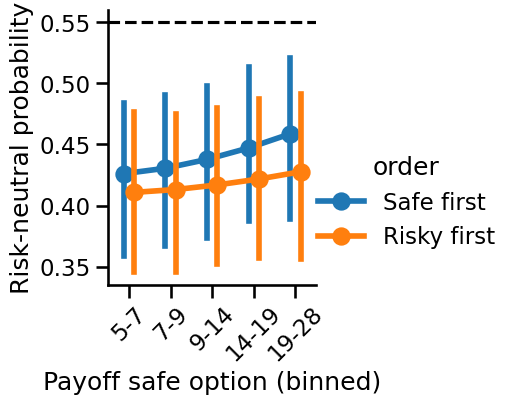

<Figure size 640x480 with 0 Axes>

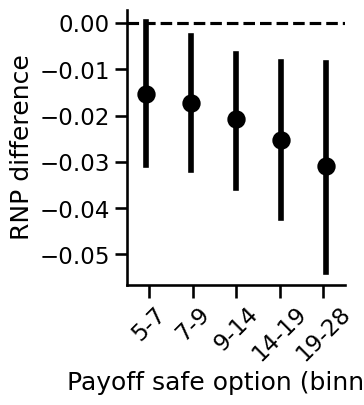

In [38]:
sns.set_context('talk')
# rnp['Order'] = rnp.index.get_level_values('order')
g = sns.catplot(x='n_safe_bin', y='rnp', data=rnp.reset_index(), hue='order', kind='point', height=4, aspect=1., errorbar=get_hdi, dodge=.25, hue_order=['Safe first', 'Risky first'],)

# g.add_legend()

plt.axhline(.55, c='k', ls='--', zorder=10)

diff = rnp.unstack('order').droplevel(0,1)

diff = (diff['Risky first'] - diff['Safe first']).to_frame("RNP difference")

plt.xticks(rotation=45)
plt.xlabel('Payoff safe option (binned)')
plt.ylabel('Risk-neutral probability')

plt.figure()
g = sns.catplot(x='n_safe_bin', y='RNP difference', data=diff.reset_index(), kind='point', height=4, aspect=1., errorbar=get_hdi, dodge=True, palette=['k'])


g.map(plt.axhline, y=0, c='k', ls='--', zorder=10)

diff.groupby('n_safe_bin').apply(lambda x: (x > 0.0).mean())

# Rotate x-ticks for better readability
plt.xticks(rotation=45)
plt.xlabel('Payoff safe option (binned)')

# g.savefig()

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_37263/3945942395.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  slope = diff.reset_index().groupby(['chain', 'draw']).apply(calculate_slope)['slope']


0.096

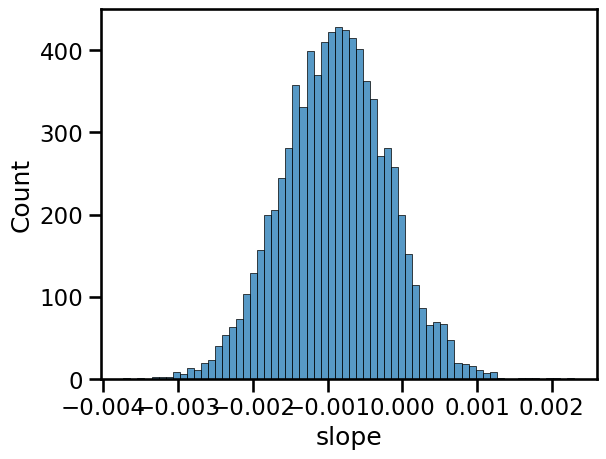

In [41]:
# Calculate the slope of the regression line for each chain and draw
def calculate_slope(group):
    x = group['n_safe_bin'].apply(lambda x: np.mean(np.array(x.split('-'), dtype=float)))
    y = group['RNP difference']
    slope, intercept, r_value, p_value, std_err = ss.linregress(x, y)
    return pd.Series({'slope': slope, 'intercept': intercept})  

slope = diff.reset_index().groupby(['chain', 'draw']).apply(calculate_slope)['slope']
sns.histplot(slope)
(slope > 0.0).mean()
